# Transformada inversa + viento

**CC2017 – Modelización y Simulaciones** · Proyecto: simulación de lanzamiento de cohete

Sección de la entrega final: método de transformada inversa aplicado al viento y a los tiempos entre anomalías.


## 1. Método de la transformada inversa

**Idea general.** Si $U \sim \mathcal{U}(0,1)$ y $F$ es la función de distribución acumulada de una variable continua y estrictamente creciente sobre su soporte, entonces

$$X = F^{-1}(U)$$

tiene distribución $F$.

**Demostración.**

$$P(X \le x) = P\big(F^{-1}(U) \le x\big) = P\big(U \le F(x)\big) = F(x),$$

ya que $U$ es uniforme en $(0,1)$, luego $P(U \le t) = t$.

**Pasos del algoritmo.**

1. Generar $U \sim \mathcal{U}(0,1)$.
2. Igualar $F(X) = U$ y despejar $X$.
3. Devolver $X = F^{-1}(U)$.

**Requisito clave.** La CDF debe poder invertirse de forma cerrada. Cuando eso ocurre el método es exacto, directo y no desperdicia generaciones (a diferencia de aceptación–rechazo), ni requiere transformaciones previas (como el método polar para normales). En cambio, no sirve cuando la CDF no es invertible analíticamente.


## 2. Derivación de la inversa de la exponencial

Queremos $X \sim \mathrm{Exp}(\lambda)$, con

$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0,$$

$$F(x) = P(X \le x) = \int_0^x \lambda e^{-\lambda t}\,dt = 1 - e^{-\lambda x}.$$

Igualamos $u = F(x)$ y despejamos $x$:

$$u = 1 - e^{-\lambda x}
\quad\Rightarrow\quad
e^{-\lambda x} = 1 - u
\quad\Rightarrow\quad
-\lambda x = \ln(1 - u)
\quad\Rightarrow\quad
\boxed{X = -\frac{\ln(1 - U)}{\lambda}}.$$

**Nota de eficiencia.** Como $1 - U \sim \mathcal{U}(0,1)$, también vale $X = -\ln(U)/\lambda$; ambas expresiones son equivalentes.

**Parámetros de la exponencial usados para la validación:**

$$\mathbb{E}[X] = \frac{1}{\lambda}, \qquad \mathrm{Var}(X) = \frac{1}{\lambda^2}.$$

**Aplicación.** El viento perturba la trayectoria y la velocidad del cohete. Modelamos la velocidad del viento $W \sim \mathrm{Exp}(\lambda_w)$ con media $12\ \mathrm{m/s}$, es decir $\lambda_w = 1/12 \approx 0.0833$. Además, los tiempos entre anomalías del sistema se modelan como $\mathrm{Exp}(\lambda_a)$ con media $300\ \mathrm{s}$, coherente con un proceso de Poisson.


In [1]:
# El módulo metodo_inversa.py contiene la implementación de la transformada inversa
import random
import inspect
import metodo_inversa

print(inspect.getsource(metodo_inversa.exponencial_inversa))

def exponencial_inversa(lmbda):
    """Genera una variable exponencial Exp(lmbda) via transformada inversa.

    X = -ln(1 - U) / lmbda  con U ~ Uniforme(0, 1).
    """
    u = random.uniform(0, 1)
    return -math.log(1.0 - u) / lmbda



## 3. Generación del viento $W$

Generamos $n = 10^6$ muestras de $W \sim \mathrm{Exp}(\lambda_w)$ con $\lambda_w = 1/12$ (media $12$ m/s). Fijamos una semilla para reproducibilidad.


In [2]:
random.seed(42)

lam_w = 1.0 / 12.0
viento = metodo_inversa.generar_viento(1_000_000, media=12.0)

print("Primeras 10 muestras de viento (m/s):")
print([round(w, 2) for w in viento[:10]])
print("Media muestral:", round(sum(viento) / len(viento), 4))

Primeras 10 muestras de viento (m/s):
[12.24, 0.3, 3.86, 3.03, 16.0, 13.55, 26.73, 1.09, 6.58, 0.36]
Media muestral: 11.9924


## 4. Tiempos entre anomalías (opcional)

Modelamos los tiempos entre anomalías como exponenciales con media $300$ s ($\lambda_a = 1/300$).


In [3]:
lam_a = 1.0 / 300.0
anomalias = metodo_inversa.generar_tiempos_anomalias(200_000, media=300.0)

print("Primeros 10 tiempos entre anomalías (s):")
print([round(t, 2) for t in anomalias[:10]])
print("Media muestral:", round(sum(anomalias) / len(anomalias), 4))

Primeros 10 tiempos entre anomalías (s):
[243.34, 15.33, 219.73, 5.37, 103.17, 144.99, 293.95, 260.78, 119.58, 199.17]
Media muestral: 300.1037


## 5. Validación de media y varianza

Para $\mathrm{Exp}(\lambda)$ se cumple $\mathbb{E}[X] = 1/\lambda$ y $\mathrm{Var}(X) = 1/\lambda^2$. Comparamos los estimadores muestrales contra los teóricos. Como validación estadística adicional, aplicamos la prueba de Kolmogorov–Smirnov contra la CDF exponencial teórica.


In [4]:
import math
from scipy import stats

def validar_exp(muestra, lmbda, nombre):
    n = len(muestra)
    media_m = sum(muestra) / n
    var_m = sum((x - media_m) ** 2 for x in muestra) / (n - 1)
    media_t = 1.0 / lmbda
    var_t = 1.0 / lmbda ** 2
    ks = stats.kstest(muestra, "expon", args=(0.0, media_t))
    print(f"[{nombre}] n = {n}")
    print(f"  Media   muestral = {media_m:9.4f} | teórica = {media_t:9.4f}")
    print(f"  Varianza muestral = {var_m:9.4f} | teórica = {var_t:9.4f}")
    print(f"  KS: estadístico = {ks.statistic:.5f}, p-valor = {ks.pvalue:.5f}")
    print()

random.seed(42)
viento = metodo_inversa.generar_viento(1_000_000, media=12.0)
anomalias = metodo_inversa.generar_tiempos_anomalias(200_000, media=300.0)

validar_exp(viento, lam_w, "Viento W")
validar_exp(anomalias, lam_a, "Tiempos entre anomalías")

[Viento W] n = 1000000
  Media   muestral =   11.9924 | teórica =   12.0000
  Varianza muestral =  143.6630 | teórica =  144.0000
  KS: estadístico = 0.00070, p-valor = 0.70290

[Tiempos entre anomalías] n = 200000
  Media   muestral =  300.1037 | teórica =  300.0000
  Varianza muestral = 89607.1896 | teórica = 90000.0000
  KS: estadístico = 0.00218, p-valor = 0.29914



## 6. Histogramas

Superponemos la PDF exponencial teórica sobre la distribución muestral para verificar visualmente el ajuste.


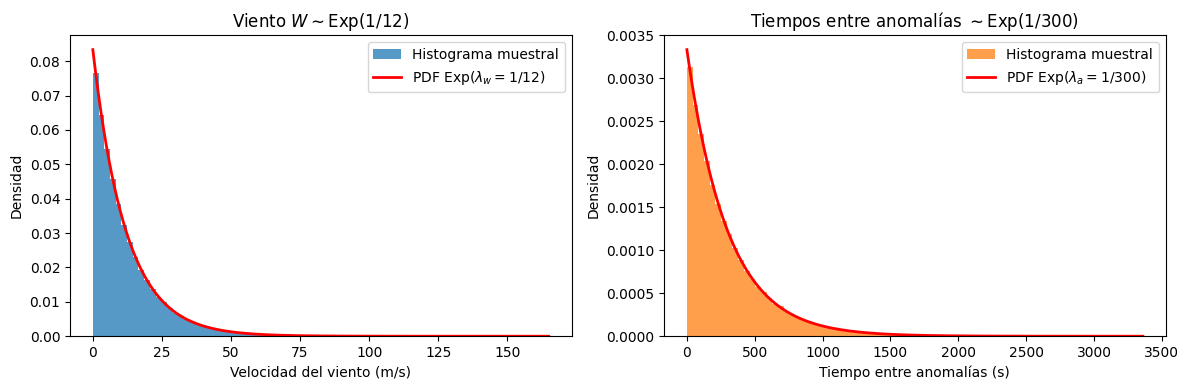

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

xw = np.linspace(0, np.max(viento), 500)
axes[0].hist(viento, bins=80, density=True, alpha=0.75, color="tab:blue",
             label="Histograma muestral")
axes[0].plot(xw, lam_w * np.exp(-lam_w * xw), "r-", lw=2,
             label=r"PDF Exp($\lambda_w = 1/12$)")
axes[0].set_xlabel("Velocidad del viento (m/s)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Viento $W \\sim \\mathrm{Exp}(1/12)$")
axes[0].legend()

xa = np.linspace(0, np.max(anomalias), 500)
axes[1].hist(anomalias, bins=80, density=True, alpha=0.75, color="tab:orange",
             label="Histograma muestral")
axes[1].plot(xa, lam_a * np.exp(-lam_a * xa), "r-", lw=2,
             label=r"PDF Exp($\lambda_a = 1/300$)")
axes[1].set_xlabel("Tiempo entre anomalías (s)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Tiempos entre anomalías $\\sim \\mathrm{Exp}(1/300)$")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Documentación — sección del informe (texto listo para el informe)

### Transformada inversa aplicada a la exponencial

El método de la transformada inversa genera una variable aleatoria $X$ con función de distribución $F$ mediante $X = F^{-1}(U)$, con $U \sim \mathcal{U}(0,1)$. Es válido porque $P(F^{-1}(U) \le x) = P(U \le F(x)) = F(x)$.

Para la distribución exponencial $F(x) = 1 - e^{-\lambda x}$, se despeja $X = -\ln(1-U)/\lambda$. La implementación es directa, exacta y no desperdicia muestras, a diferencia de la aceptación–rechazo.

### Variables generadas

| Variable | Distribución | Parámetro | Uso |
|---|---|---|---|
| Viento $W$ | $\mathrm{Exp}(\lambda_w)$ | $\lambda_w = 1/12$ (media $12$ m/s) | Perturbación de la trayectoria/velocidad del cohete |
| Tiempo entre anomalías | $\mathrm{Exp}(\lambda_a)$ | $\lambda_a = 1/300$ (media $300$ s) | Instantes de fallas del sistema (proceso de Poisson) |

### Resultados de la validación

Para $n$ muestras se estimaron media y varianza muestrales y se compararon con los valores teóricos $1/\lambda$ y $1/\lambda^2$ (ver celdas anteriores). Adicionalmente, la prueba de Kolmogorov–Smirnov no rechazó la hipótesis nula de que las muestras provienen de la exponencial teórica ($p \gg 0.05$), y los histogramas superpuestos confirmaron visualmente el ajuste. Esto valida que el generador por transformada inversa produce variables correctamente distribuidas.

### Comparación con el método polar (referencia)

El método polar genera variables normales para modelar la velocidad del cohete $V \sim \mathcal{N}(7800, 100^2)$, mientras que aquí la transformada inversa genera exponenciales para el viento y las anomalías. Cada variable usa el mecanismo más natural según su distribución: inversa exacta para exponenciales (sin rechazos) y polar para normales. El criterio de comparación entre métodos se detalla en la sección de resultados: ambos generadores pasan las pruebas de bondad de ajuste sobre su respectiva distribución.
